In [1]:
# ── Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import joblib
import json
import os

In [2]:
# ── Load Data ────────────────────────────────────────
df = pd.read_csv('data/processed/df_with_segment_labels.csv')

X = df.drop(['Churn', 'segment_label'], axis=1)
y = df['Churn']

print(f"Dataset shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")

Dataset shape: (7032, 20)
Class distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [3]:
# ── Constants ────────────────────────────────────────
SEED = 42

# ── Split: 70% train | 15% val | 15% test ────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=SEED
)  # 0.1765 of 85% ≈ 15% of total

print(f"Train : {X_train.shape[0]} rows")
print(f"Val   : {X_val.shape[0]} rows")
print(f"Test  : {X_test.shape[0]} rows")

# ── Identify column types ─────────────────────────────
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols  = [col for col in X.columns if col not in num_cols]

print(f"\nNumeric cols : {num_cols}")
print(f"Categorical cols: {cat_cols}")

Train : 4922 rows
Val   : 1055 rows
Test  : 1055 rows

Numeric cols : ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical cols: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'segment']


In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── Build Preprocessor ───────────────────────────────
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),        num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

# ── Fit ONLY on train, transform all splits ──────────
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc   = preprocessor.transform(X_val)
X_test_enc  = preprocessor.transform(X_test)

# ── Combine train+val for final retraining ───────────
X_trainval_enc = np.vstack([X_train_enc, X_val_enc])
y_trainval     = pd.concat([y_train, y_val]).reset_index(drop=True)

print(f"X_train_enc shape : {X_train_enc.shape}")
print(f"X_val_enc shape   : {X_val_enc.shape}")
print(f"X_test_enc shape  : {X_test_enc.shape}")
print(f"X_trainval_enc shape : {X_trainval_enc.shape}")
print(f"\nPreprocessor fitted ✅")

X_train_enc shape : (4922, 33)
X_val_enc shape   : (1055, 33)
X_test_enc shape  : (1055, 33)
X_trainval_enc shape : (5977, 33)

Preprocessor fitted ✅


In [5]:
# ── Phase 2 Best Params ──────────────────────────────
lgbm_best_params = {
    'n_estimators'     : 650,
    'max_depth'        : 13,
    'learning_rate'    : 0.008535633844517027,
    'num_leaves'       : 13,
    'min_child_samples': 21,
    'subsample'        : 0.7580026562631494,
    'colsample_bytree' : 0.6066081804708111,
    'reg_alpha'        : 0.15703551247124883,
    'reg_lambda'       : 2.884795719882881,
    'scale_pos_weight' : 1.710339753731322,
    'min_split_gain'   : 0.43601254903789377,
    'subsample_freq'   : 4
}

# ── Train on full train+val set ──────────────────────
final_lgbm = LGBMClassifier(
    **lgbm_best_params,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

final_lgbm.fit(X_trainval_enc, y_trainval)

print("LightGBM trained on train+val ✅")
print(f"Total trees built : {final_lgbm.n_estimators_}")

LightGBM trained on train+val ✅
Total trees built : 650


  Test ROC-AUC : 0.8398

── Default Threshold (0.5) ──────────────────────
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84       775
       Churn       0.56      0.70      0.62       280

    accuracy                           0.78      1055
   macro avg       0.72      0.75      0.73      1055
weighted avg       0.80      0.78      0.78      1055


── Optimal Threshold (0.436) ──────────────────
              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82       775
       Churn       0.53      0.79      0.63       280

    accuracy                           0.76      1055
   macro avg       0.72      0.77      0.73      1055
weighted avg       0.81      0.76      0.77      1055



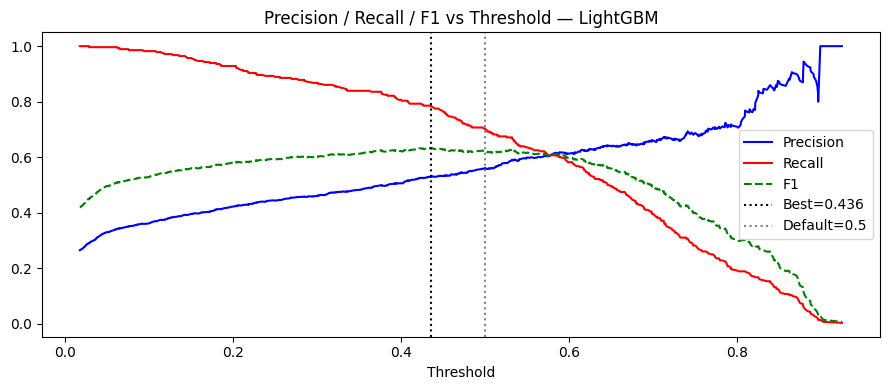

In [6]:
from sklearn.metrics import precision_recall_curve, f1_score

# ── Test Set Probabilities ───────────────────────────
lgbm_proba = final_lgbm.predict_proba(X_test_enc)[:, 1]

# ── Baseline at 0.5 ──────────────────────────────────
y_pred_default = (lgbm_proba >= 0.5).astype(int)
default_auc = roc_auc_score(y_test, lgbm_proba)

print("=" * 50)
print(f"  Test ROC-AUC : {default_auc:.4f}")
print("=" * 50)
print("\n── Default Threshold (0.5) ──────────────────────")
print(classification_report(y_test, y_pred_default, target_names=['No Churn', 'Churn']))

# ── Find Optimal Threshold via F1 ────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, lgbm_proba)
f1_scores    = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx     = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

y_pred_tuned = (lgbm_proba >= best_threshold).astype(int)

print(f"\n── Optimal Threshold ({best_threshold:.3f}) ──────────────────")
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn', 'Churn']))

# ── Precision / Recall / F1 vs Threshold Plot ────────
plt.figure(figsize=(9, 4))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='red')
plt.plot(thresholds, f1_scores[:-1],  label='F1',        color='green', linestyle='--')
plt.axvline(best_threshold, color='black', linestyle=':', label=f'Best={best_threshold:.3f}')
plt.axvline(0.5,            color='gray',  linestyle=':', label='Default=0.5')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs Threshold — LightGBM')
plt.legend()
plt.tight_layout()
plt.show()

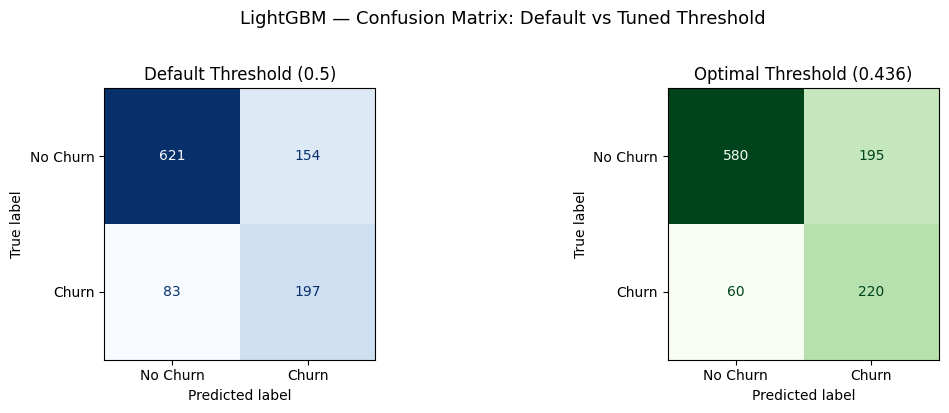


Metric                     Default (0.5)  Tuned (0.436)      Delta
─────────────────────────────────────────────────────────────────
True Positives (TP)                  197            220        +23
False Negatives (FN)                  83             60        -23
False Positives (FP)                 154            195        +41
True Negatives (TN)                  621            580        -41


In [7]:
# ── Side-by-side Confusion Matrix ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Default threshold (0.5)
cm_default = confusion_matrix(y_test, y_pred_default)
ConfusionMatrixDisplay(
    confusion_matrix=cm_default,
    display_labels=['No Churn', 'Churn']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Default Threshold (0.5)', fontsize=12)

# Optimal threshold
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=['No Churn', 'Churn']
).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Optimal Threshold ({best_threshold:.3f})', fontsize=12)

plt.suptitle('LightGBM — Confusion Matrix: Default vs Tuned Threshold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Delta Summary ─────────────────────────────────────
tn_d, fp_d, fn_d, tp_d = cm_default.ravel()
tn_t, fp_t, fn_t, tp_t = cm_tuned.ravel()

print(f"\n{'Metric':<25} {'Default (0.5)':>14} {'Tuned ({:.3f})'.format(best_threshold):>14} {'Delta':>10}")
print("─" * 65)
print(f"{'True Positives (TP)':<25} {tp_d:>14} {tp_t:>14} {tp_t - tp_d:>+10}")
print(f"{'False Negatives (FN)':<25} {fn_d:>14} {fn_t:>14} {fn_t - fn_d:>+10}")
print(f"{'False Positives (FP)':<25} {fp_d:>14} {fp_t:>14} {fp_t - fp_d:>+10}")
print(f"{'True Negatives (TN)':<25} {tn_d:>14} {tn_t:>14} {tn_t - tn_d:>+10}")

In [8]:
# ── Create Directory ─────────────────────────────────
os.makedirs("../models/churn", exist_ok=True)

# ── Save LightGBM Model ──────────────────────────────
joblib.dump(final_lgbm, "../models/churn/lgbm_churn_model.pkl")
print("LightGBM model saved ✅")

# ── Save Preprocessor ───────────────────────────────
joblib.dump(preprocessor, "../models/churn/preprocessor.pkl")
print("Preprocessor saved ✅")

# ── Save Threshold Metadata ──────────────────────────
threshold_meta = {
    'best_threshold'   : float(best_threshold),
    'default_threshold': 0.5,
    'metric_optimized' : 'F1',
    'test_roc_auc'     : float(default_auc)
}
with open("../models/churn/threshold_meta.json", 'w') as f:
    json.dump(threshold_meta, f, indent=4)
print("Threshold metadata saved ✅")

# ── Verify ───────────────────────────────────────────
print(f"\n{'─'*45}")
print("  Saved artifacts:")
print(f"{'─'*45}")
for file in sorted(os.listdir("../models/churn")):
    size_kb = os.path.getsize(f"../models/churn/{file}") / 1024
    print(f"  {file:<40} {size_kb:>6.1f} KB")
print(f"{'─'*45}")

LightGBM model saved ✅
Preprocessor saved ✅
Threshold metadata saved ✅

─────────────────────────────────────────────
  Saved artifacts:
─────────────────────────────────────────────
  lgbm_churn_model.pkl                     1000.0 KB
  preprocessor.pkl                            7.1 KB
  threshold_meta.json                         0.1 KB
─────────────────────────────────────────────
